# 2단계: 지역별 400셀 1차원 LHS 샘플링 (`sampling.pkl`)

`all.pkl`(1단계 `make_all_pkl.ipynb` 출력)에서 지역마다 400셀을 뽑아 CA 모델 입력을 만듭니다.

### 방법: 셀 단위 1차원 LHS (중복 제거)
지역의 셀은 `all.pkl`에서 **래스터 순서**(북→남, 같은 행은 서→동)로 정렬되어 있습니다. 이 순서를 400개 층으로 나누고
층마다 셀 하나를 독립적으로 무작위 추출합니다(1차원 LHS). 행 순서가 위도를 따르므로 공간적으로도 층화됩니다.

- **후보 n ≥ 400**: 셀을 연속한 400개 묶음(크기 ⌊n/400⌋ 또는 ⌈n/400⌉)으로 나누고 묶음마다 셀 하나를 무작위로 뽑습니다.
  묶음끼리 셀이 겹치지 않으므로 **중복이 없습니다**. 큰 묶음(⌈n/400⌉)의 위치는 무작위로 정해, 모든 셀의 뽑힐 확률이 400/n으로 같게 합니다
  (큰 묶음을 한쪽에 몰면 그쪽 셀이 덜 뽑혀 평균이 치우칩니다).
- **후보 n < 400**: 400개 층을 셀 순서대로 나눠 셀마다 ⌊400/n⌋ 또는 ⌈400/n⌉개 층을 맡깁니다(⌈400/n⌉을 받을 셀은 무작위).
  모든 셀을 쓰고 **반복 횟수가 고르게** 됩니다.
- **20×20 배치**: CA 모델은 400개 값을 순서대로 `reshape(20, 20)` 합니다. 뽑은 400셀의 순서는 무작위로 섞습니다.
- **시나리오 간 동일 위치**: 위치는 지역마다 한 번만 정해 12개 시나리오에 똑같이 적용합니다.
- **재현성**: 난수는 `SEED`와 지역 이름(md5)으로 만든 생성기를 씁니다. 실행 순서나 지역 추가와 관계없이 같은 결과가 나옵니다.

### 기존 방식과의 차이
- 기존(제출 논문, `archive/sampling_1D_original.pkl`): `qmc.LatinHypercube(d=2)`의 첫 열(1차원 LHS)로 행 번호를 고름. 치우침은 없지만,
  연속값을 정수로 자르면서 이웃 층이 같은 셀에 떨어져 **중복·누락**이 생김(후보 ≥ 400 지역에서 고유 셀 348~396개). 시드 미고정.
- 2Dfixed(`archive/sampling_2Dfixed_20260926.pkl`): x·y 순위 공간 2D 층화. 중복은 없지만 불규칙한 지역에서 경계 셀을 과하게 뽑아
  **평균 적합도가 치우침**(34개 중 19개 지역, 최대 0.027). 사용하지 않음.

### 입력 / 출력
- 입력: `DATA/SDM_data/latin/TES_maxent/all.pkl`
- 출력: `DATA/SDM_data/latin/TES_maxent/sampling.pkl` — `{시나리오: {지역: 400행 DataFrame(x, y, {시나리오}, SIG_ENG_NM)}}`

In [1]:
import os
import hashlib
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. 경로 설정 및 `all.pkl` 불러오기

In [2]:
# 이 저장소(PDSI)를 어디에 클론해도 동작하도록, 위쪽 폴더에서 "PDSI" git 저장소를 찾아
# 그 형제 폴더인 "DATA"를 데이터 루트로 씁니다. 다른 위치면 환경변수 PDSI_DATA_ROOT 로 지정하세요.
def _find_project_root(marker="PDSI"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if candidate.name == marker and (candidate / ".git").exists():
            return candidate
    return None

_env_override = os.environ.get("PDSI_DATA_ROOT")
if _env_override:
    base = Path(_env_override)
else:
    _root = _find_project_root()
    if _root is None:
        raise FileNotFoundError(
            "'PDSI' 저장소 폴더를 상위 경로에서 찾지 못했습니다. "
            "환경변수 PDSI_DATA_ROOT 에 DATA 폴더의 상위 경로를 직접 지정하세요."
        )
    base = _root.parent

sdm_data_path = base / 'DATA' / 'SDM_data'
maxent_path = sdm_data_path / 'Maxent'                        # ① MaxEnt 서식지 적합성 지도 (시나리오별 CSV)
latlong_file = sdm_data_path / 'latin' / 'latlong_ex.xlsx'
local_index_file = sdm_data_path / 'latin' / 'local_index.csv'
species_output_path = sdm_data_path / 'latin' / 'TES_maxent'
all_file = species_output_path / 'all.pkl'
sampling_file = species_output_path / 'sampling.pkl'

scenarios = [
    'ssp126_2030', 'ssp126_2050', 'ssp126_2070', 'ssp126_2090',
    'ssp245_2030', 'ssp245_2050', 'ssp245_2070', 'ssp245_2090',
    'ssp585_2030', 'ssp585_2050', 'ssp585_2070', 'ssp585_2090',
]
print(f'데이터 루트(base): {base}')
with open(all_file, 'rb') as f:
    maxent_datas = pickle.load(f)
assert list(maxent_datas) == scenarios, list(maxent_datas)
local_values = list(maxent_datas[scenarios[0]])
print(f'{len(maxent_datas)}개 시나리오 × {len(local_values)}개 지역')

데이터 루트(base): <DATA 루트>
12개 시나리오 × 167개 지역


## 2. 셀 단위 1차원 LHS 함수

In [3]:
NUM_SAMPLES = 400
SEED = 0

def district_rng(district_name, seed=SEED):
    """지역 이름 + 전체 시드로 만든 난수 생성기 (실행 순서·지역 추가와 무관하게 같은 값)."""
    name_key = int(hashlib.md5(district_name.encode('utf-8')).hexdigest(), 16) % (2**32)
    return np.random.default_rng([seed, name_key])

def lhs_1d_positions(n, num_samples, rng):
    """래스터 순서로 정렬된 셀 n개에서 num_samples개 위치(.iloc용)를 층 순서대로 반환합니다."""
    if n >= num_samples:
        q, r = divmod(n, num_samples)
        sizes = np.full(num_samples, q)
        sizes[rng.choice(num_samples, r, replace=False)] += 1      # 큰 묶음 위치는 무작위
        starts = np.r_[0, np.cumsum(sizes)[:-1]]
        return starts + (rng.random(num_samples) * sizes).astype(int)   # 묶음마다 셀 하나
    counts = np.full(n, num_samples // n)
    counts[rng.choice(n, num_samples % n, replace=False)] += 1      # ⌈N/n⌉번 쓸 셀은 무작위
    return np.repeat(np.arange(n), counts)

def sample_positions(district_name, n, num_samples=NUM_SAMPLES):
    rng = district_rng(district_name)
    positions = lhs_1d_positions(n, num_samples, rng)
    return positions[rng.permutation(num_samples)]                 # 20×20 배치 무작위

## 3. 지역별 위치 확정 (한 번만) 및 시나리오별 적용

In [4]:
ref_cells = maxent_datas[scenarios[0]]
for name, df in ref_cells.items():   # 셀이 래스터 순서(위도 내림차순, 같은 위도는 경도 오름차순)인지 확인
    dy, dx = np.diff(df['y'].values), np.diff(df['x'].values)
    assert np.all((dy < 0) | ((np.abs(dy) < 1e-9) & (dx > 0))), f'{name}: 래스터 순서가 아닙니다'

district_positions = {name: sample_positions(name, len(ref_cells[name])) for name in local_values}

maxent_datas_sampling = {
    s: {name: maxent_datas[s][name].iloc[district_positions[name]] for name in local_values}
    for s in scenarios
}

n_cand = pd.Series({k: len(v) for k, v in ref_cells.items()})
counts = {k: np.bincount(p, minlength=n_cand[k]) for k, p in district_positions.items()}
big, small = n_cand[n_cand >= NUM_SAMPLES].index, n_cand[n_cand < NUM_SAMPLES].index
print(f'후보 셀 수: 최소 {n_cand.min()}, 최대 {n_cand.max()}')
print(f'후보 ≥ 400인 지역 {len(big)}개 — 모두 400개 고유 셀: {all(counts[k].max() == 1 for k in big)}')
print(f'후보 < 400인 지역 {len(small)}개 — 모든 셀을 ⌊400/n⌋~⌈400/n⌉번 사용: '
      f'{all(counts[k].min() == NUM_SAMPLES // n_cand[k] and counts[k].max() == -(-NUM_SAMPLES // n_cand[k]) for k in small)}')

후보 셀 수: 최소 48, 최대 2677
후보 ≥ 400인 지역 139개 — 모두 400개 고유 셀: True
후보 < 400인 지역 28개 — 모든 셀을 ⌊400/n⌋~⌈400/n⌉번 사용: True


## 4. 검증

In [5]:
ref = maxent_datas_sampling[scenarios[0]]
for s in scenarios:
    for name in local_values:
        smp = maxent_datas_sampling[s][name]
        assert len(smp) == NUM_SAMPLES
        # 모든 시나리오에서 같은 셀이 같은 순서(같은 칸)로 선택됨
        assert smp.index.equals(ref[name].index)
        assert np.array_equal(smp[['x', 'y']].values, ref[name][['x', 'y']].values)
        # 값이 all.pkl과 일치
        assert np.array_equal(smp[s].values, maxent_datas[s][name].loc[smp.index, s].values)
        assert smp[s].between(0, 1).all()

# 20×20 배치가 공간 순서와 무관한지 (순서-좌표 상관이 0 근처여야 함)
order = np.arange(NUM_SAMPLES)
corr_x = np.nanmean([np.corrcoef(order, ref[n]['x'])[0, 1] for n in local_values])
corr_y = np.nanmean([np.corrcoef(order, ref[n]['y'])[0, 1] for n in local_values])
# 대표성: 샘플 평균 적합도 vs 지역 전체 평균
gap = pd.Series({n: np.mean([maxent_datas_sampling[s][n][s].mean() - maxent_datas[s][n][s].mean() for s in scenarios])
                 for n in local_values})
print('✓ 모든 지역 400셀, 시나리오 간 동일 위치·순서, 값 = all.pkl, 범위 [0, 1]')
print(f'샘플 평균 - 지역 전체 평균 (12개 시나리오 평균): |평균| {gap.abs().mean():.4f}, 최대 {gap.abs().max():.4f}')
print(f'평균 corr(순서, x) = {corr_x:.3f}, corr(순서, y) = {corr_y:.3f}')

✓ 모든 지역 400셀, 시나리오 간 동일 위치·순서, 값 = all.pkl, 범위 [0, 1]
샘플 평균 - 지역 전체 평균 (12개 시나리오 평균): |평균| 0.0029, 최대 0.0120
평균 corr(순서, x) = -0.003, corr(순서, y) = 0.008


## 5. 저장

In [6]:
with open(sampling_file, 'wb') as f:
    pickle.dump(maxent_datas_sampling, f)
print(f'✓ {sampling_file}')

✓ <DATA 루트>/DATA/SDM_data/latin/TES_maxent/sampling.pkl


## 6. 결과 확인

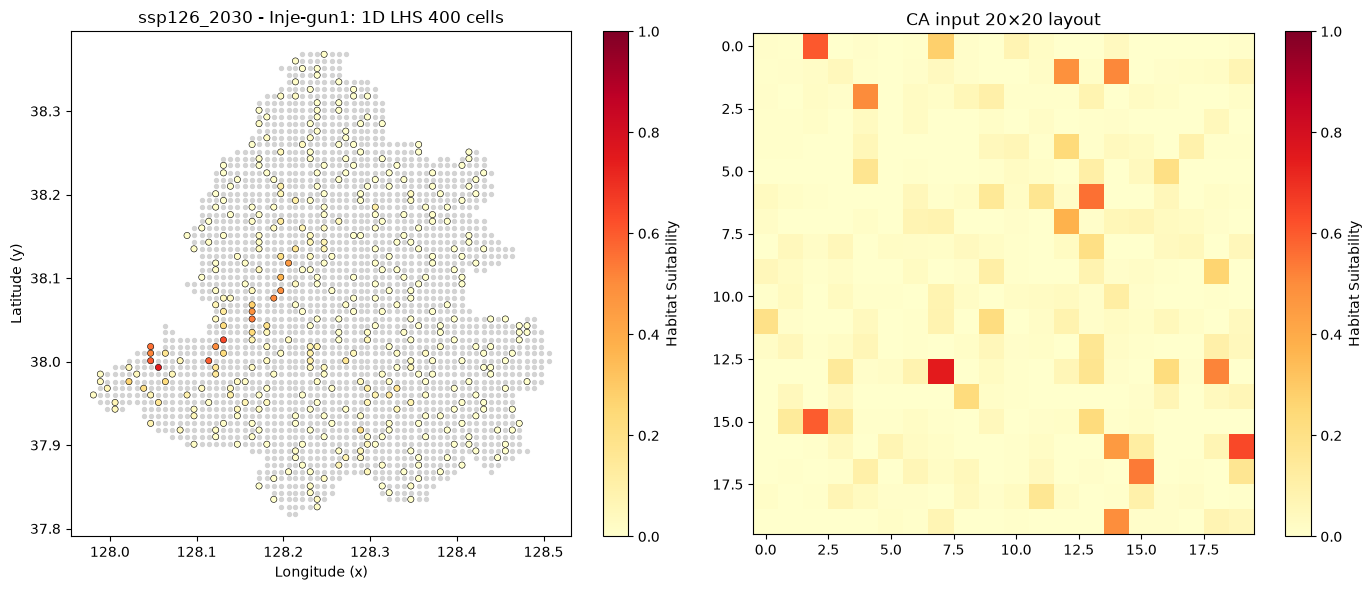

In [7]:
scenario_example = 'ssp126_2030'
region_example = 'Inje-gun1'
cand = maxent_datas[scenario_example][region_example]
sample = maxent_datas_sampling[scenario_example][region_example]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(cand['x'], cand['y'], c='lightgray', s=8, label='candidate cells')
sc = axes[0].scatter(sample['x'], sample['y'], c=sample[scenario_example], cmap='YlOrRd',
                     vmin=0, vmax=1, edgecolors='black', linewidth=0.4, s=20)
fig.colorbar(sc, ax=axes[0], label='Habitat Suitability')
axes[0].set_xlabel('Longitude (x)')
axes[0].set_ylabel('Latitude (y)')
axes[0].set_title(f'{scenario_example} - {region_example}: 1D LHS 400 cells')

im = axes[1].imshow(sample[scenario_example].values.reshape(20, 20), cmap='YlOrRd', vmin=0, vmax=1)
fig.colorbar(im, ax=axes[1], label='Habitat Suitability')
axes[1].set_title('CA input 20×20 layout')
plt.tight_layout()
plt.show()